In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from tensorflow.keras.layers import LSTM,GRU
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


# **Read and Explore the Data**

In [2]:
train_df=pd.read_csv(r"C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Twitter Sentment Analysis\twitter_training.csv")
val_df=pd.read_csv(r"C:\Users\AbdElhalk\OneDrive\Desktop\NLP Projects\Twitter Sentment Analysis\twitter_validation.csv")



In [3]:
train_df.head(30)

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
5,2402,Borderlands,Positive,So I spent a few hours making something for fu...
6,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
7,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
8,2402,Borderlands,Positive,So I spent a few hours making something for fu...
9,2402,Borderlands,Positive,2010 So I spent a few hours making something f...


In [4]:
print(train_df.info())
print("___"*50)
print(train_df.describe())
print("___"*50)
print(train_df.isnull().sum())
print("___"*50)
print(train_df.duplicated().sum())
print("___"*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None
______________________________________________________________________________________________________________________________________________________
               2401
count  74681.000000
mean    6432.640149
std     3740.423819
min        1.000000
25%     3195.000000
50%     6422.000000
75%     9601.000000
max    13200.000000
________

In [5]:
train_df.drop(columns=["2401","Borderlands"],inplace=True)

In [6]:
train_df.rename(
    
   columns= {
        "im getting on borderlands and i will murder you all ," : "Text",
        "Positive":"Sentiment"
    },
    
    inplace=True
)

In [7]:
train_df=train_df[["Text","Sentiment"]]

In [8]:
train_df

,Text,Sentiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
74676,Just realized that the Windows partition of my...,Positive
74677,Just realized that my Mac window partition is ...,Positive
74678,Just realized the windows partition of my Mac ...,Positive
74679,Just realized between the windows partition of...,Positive


In [9]:
train_df.duplicated(subset=["Text"]).sum()

np.int64(5190)

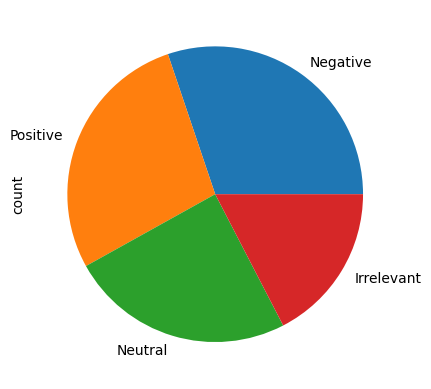

In [10]:
plot=train_df["Sentiment"].value_counts().plot(kind="pie")


---

In [11]:
val_df.head(30)

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
5,7925,MaddenNFL,Positive,Thank you @EAMaddenNFL!! \n\nNew TE Austin Hoo...
6,11332,TomClancysRainbowSix,Positive,"Rocket League, Sea of Thieves or Rainbow Six: ..."
7,1107,AssassinsCreed,Positive,my ass still knee-deep in Assassins Creed Odys...
8,2069,CallOfDuty,Negative,FIX IT JESUS ! Please FIX IT ! What In the wor...
9,3185,Dota2,Positive,The professional dota 2 scene is fucking explo...


In [12]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column                                                                                                                                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                              --------------  ----- 
 0   3364                                                                                                                                                                                                                                                999 non-null    int64 
 1   Facebook                                                                   

In [13]:
val_df.isnull().sum()

3364                                                                                                                                                                                                                                                  0
Facebook                                                                                                                                                                                                                                              0
Irrelevant                                                                                                                                                                                                                                            0
I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣    0
dtype: i

In [14]:
val_df.duplicated().sum()

np.int64(0)

In [15]:
val_df.drop(columns=["3364","Facebook"],inplace=True)

In [16]:
val_df.rename(
    columns={
        "I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣":"Text",
        "Irrelevant":"Sentiment"
    },
    inplace=True
)

In [17]:
val_df=val_df[["Text","Sentiment"]]

In [18]:
val_df

,Text,Sentiment
0,BBC News - Amazon boss Jeff Bezos rejects clai...,Neutral
1,@Microsoft Why do I pay for WORD when it funct...,Negative
2,"CSGO matchmaking is so full of closet hacking,...",Negative
3,Now the President is slapping Americans in the...,Neutral
4,Hi @EAHelp I’ve had Madeleine McCann in my cel...,Negative
...,...,...
994,⭐️ Toronto is the arts and culture capital of ...,Irrelevant
995,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...,Irrelevant
996,Today sucked so it’s time to drink wine n play...,Positive
997,Bought a fraction of Microsoft today. Small wins.,Positive


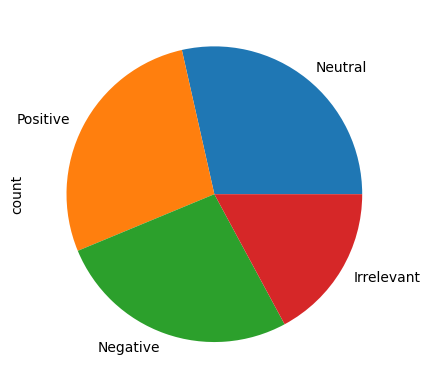

In [19]:
plot=val_df["Sentiment"].value_counts().plot(kind="pie")


---

# **CLEAN DATA**

In [20]:
train_df.dropna(inplace=True)
print(train_df.isnull().sum())
print("="*20)
train_df.drop_duplicates(subset=['Text'],inplace=True)
print(train_df.duplicated().sum())

Text         0
Sentiment    0
dtype: int64
0


---

# **Clean the Texts** 

In [21]:
def clean_text(text):
    """
    Perform light text cleaning for deep learning models.
    """

    text = re.sub(r"<.*?>", "", text)


    text = re.sub(r"http\S+|www\S+", "", text)


    text = re.sub(r"\s+", " ", text)

  
    return text.strip()


In [22]:
train_df["Text"]=train_df["Text"].apply(clean_text)
val_df["Text"]=val_df["Text"].apply(clean_text)

In [23]:
train_df

,Text,Sentiment
0,I am coming to the borders and I will kill you...,Positive
1,im getting on borderlands and i will kill you ...,Positive
2,im coming on borderlands and i will murder you...,Positive
3,im getting on borderlands 2 and i will murder ...,Positive
4,im getting into borderlands and i can murder y...,Positive
...,...,...
74676,Just realized that the Windows partition of my...,Positive
74677,Just realized that my Mac window partition is ...,Positive
74678,Just realized the windows partition of my Mac ...,Positive
74679,Just realized between the windows partition of...,Positive


In [24]:
train_df["Text"][20]

'that was the first borderlands session in a long time where i actually enjoyed a really satisfying combat experience. i got some rather good kills'

---


# **Tokenization**

In [25]:
Vocab_size=20000
tokenizer=Tokenizer(
    num_words=Vocab_size,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,    
)
tokenizer.fit_on_texts(train_df["Text"])

train_sequences = tokenizer.texts_to_sequences(train_df["Text"])
val_sequences = tokenizer.texts_to_sequences(val_df["Text"])

In [26]:
train_df["Sentiment"].value_counts()

Sentiment
Negative      21166
Positive      19066
Neutral       17042
Irrelevant    12216
Name: count, dtype: int64

In [27]:
val_df["Sentiment"].value_counts()

Sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64

In [28]:
label_maping={
    
    "Neutral"     : 0,
    "Positive"    :  1,
    "Negative"    : 2,
    "Irrelevant"  :  3
    
}
Sentiment_val=val_df["Sentiment"].map(label_maping)
Sentiment_train=train_df["Sentiment"].map(label_maping)

In [29]:
Sentiment_val.value_counts()

Sentiment
0    285
1    277
2    266
3    171
Name: count, dtype: int64

In [30]:
Sentiment_train.value_counts()

Sentiment
2    21166
1    19066
0    17042
3    12216
Name: count, dtype: int64

---

# **spliting the data**

In [31]:
X_train=train_sequences
Y_train=Sentiment_train


X_val=val_sequences
Y_val=Sentiment_val

---

# **Padding the Sequence**

In [32]:
MAX_LENGTH=100

X_train=pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="pre"
)

X_val=pad_sequences(
    X_val,
    maxlen=MAX_LENGTH,
    padding="pre",
    truncating="pre"
)


---

# **Build The SimpleRNN Model**

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [34]:
Modelrnn=tf.keras.models.Sequential([
    
    tf.keras.layers.Input(shape=(MAX_LENGTH,)),
    
    tf.keras.layers.Embedding(
        input_dim=Vocab_size,
        output_dim=100,
        mask_zero=True
    ),
    
    tf.keras.layers.SimpleRNN(
        dropout=0.2,
        recurrent_dropout=0.2,
        units=64,
        activation="tanh",
        return_sequences=False
    ),

    # Binary classification output
    tf.keras.layers.Dense(
        units=4,
        activation="softmax"
    )
])

Modelrnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,010,820 (7.67 MB)

 Trainable params: 2,010,820 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
Modelrnn.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
# Train the model
history = Modelrnn.fit(

    X_train,
    Y_train,

    batch_size=128,
    epochs=20,
    verbose=1,
    callbacks=[early_stop],
    validation_data=(X_val,Y_val)

)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.5042 - loss: 1.1424 - val_accuracy: 0.7618 - val_loss: 0.6721
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.7759 - loss: 0.6031 - val_accuracy: 0.8609 - val_loss: 0.3964
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8541 - loss: 0.4012 - val_accuracy: 0.8799 - val_loss: 0.3663
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.8891 - loss: 0.3058 - val_accuracy: 0.8839 - val_loss: 0.3626
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9117 - loss: 0.2459 - val_accuracy: 0.8779 - val_loss: 0.3904
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9249 - loss: 0.2094 - val_accuracy: 0.8869 - val_loss: 0.3772
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9329 - loss: 0.1866 - val_accuracy: 0.8849 - val_loss: 0.3970


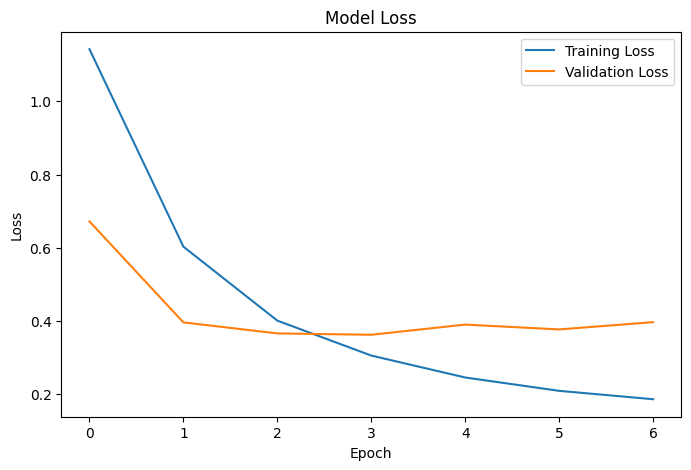

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

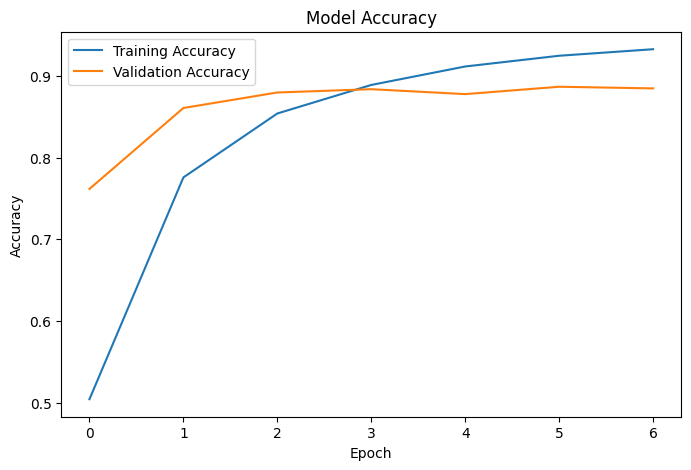

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


In [38]:
Modelrnn.evaluate(X_val,Y_val)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8839 - loss: 0.3626


[0.36255931854248047, 0.8838838934898376]

In [39]:
def predict_sentiment(Text,Modelrnn):

    Text = clean_text(Text)

    sequence = tokenizer.texts_to_sequences([Text])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="pre",
        truncating="pre"
    )

    prediction = Modelrnn.predict(
        padded,
        verbose=0
    )[0]

    labels = {
        0: "Neutral",
        1: "Positive",
        2: "Negative",
        3: "Irrelevant"
    }

    predicted_class = np.argmax(prediction)

    sentiment = labels[predicted_class]

    confidence = prediction[predicted_class]

    print(f"Text       : {Text}")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {confidence:.4f}")

In [40]:
predict_sentiment("Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!",Modelrnn)

print("="*50)

predict_sentiment("This update completely ruined the app. It's slow, full of bugs, and keeps crashing.",Modelrnn)



Text       : Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!
Sentiment  : Irrelevant
Confidence : 0.6645
Text       : This update completely ruined the app. It's slow, full of bugs, and keeps crashing.
Sentiment  : Negative
Confidence : 0.9973


---

# **Build The LSTM Model**

In [41]:
lstm_model = tf.keras.models.Sequential([
    
    tf.keras.layers.Input(shape=(MAX_LENGTH,)),

    
    tf.keras.layers.Embedding(
        input_dim=Vocab_size,
        output_dim=128,
        mask_zero=True
    ),
    
    tf.keras.layers.LSTM(
        units=64,
        activation="tanh",
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2

    ),

    tf.keras.layers.Dense(

        units=4,

        activation="softmax"

    )

])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,668 (9.96 MB)

 Trainable params: 2,609,668 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history1 = lstm_model.fit(

    X_train,
    Y_train,

    batch_size=128,
    epochs=20,
    verbose=1,
    callbacks=[early_stop],
    validation_data=(X_val,Y_val)

)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 63s 112ms/step - accuracy: 0.6718 - loss: 0.8365 - val_accuracy: 0.8929 - val_loss: 0.3306
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 82s 151ms/step - accuracy: 0.8601 - loss: 0.3972 - val_accuracy: 0.9419 - val_loss: 0.2120
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 50s 92ms/step - accuracy: 0.8966 - loss: 0.2897 - val_accuracy: 0.9419 - val_loss: 0.1836
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9177 - loss: 0.2309 - val_accuracy: 0.9499 - val_loss: 0.1635
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 48s 88ms/step - accuracy: 0.9334 - loss: 0.1879 - val_accuracy: 0.9510 - val_loss: 0.1697
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.9432 - loss: 0.1587 - val_accuracy: 0.9560 - val_loss: 0.1663
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.9512 - loss: 0.1377 - val_accuracy: 0.9550 - val_loss: 0.1686


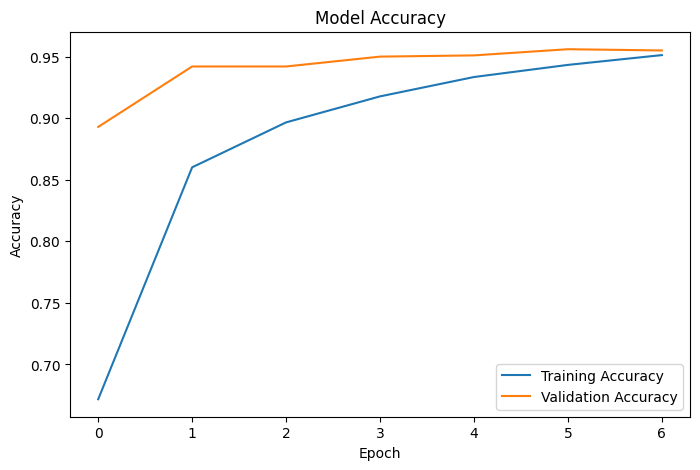

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    history1.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history1.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


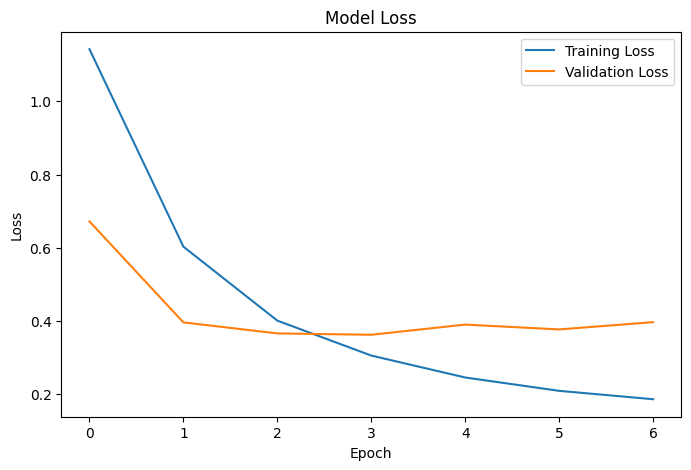

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [45]:
lstm_model.evaluate(X_val,Y_val)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9499 - loss: 0.1635


[0.16345205903053284, 0.9499499201774597]

In [46]:
def predict_sentiment(Text,lstm_model):

    Text = clean_text(Text)

    sequence = tokenizer.texts_to_sequences([Text])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="pre",
        truncating="pre"
    )

    prediction = lstm_model.predict(
        padded,
        verbose=0
    )[0]

    labels = {
        0: "Neutral",
        1: "Positive",
        2: "Negative",
        3: "Irrelevant"
    }

    predicted_class = np.argmax(prediction)

    sentiment = labels[predicted_class]

    confidence = prediction[predicted_class]

    print(f"Text       : {Text}")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {confidence:.4f}")

In [47]:

predict_sentiment("Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!",lstm_model)

print("="*50)

predict_sentiment("This update completely ruined the app. It's slow, full of bugs, and keeps crashing.",lstm_model)



Text       : Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!
Sentiment  : Positive
Confidence : 0.9866
Text       : This update completely ruined the app. It's slow, full of bugs, and keeps crashing.
Sentiment  : Negative
Confidence : 0.9999


In [48]:
lstm_model.save("backend/sentiment_model.keras")

---

# **Build The GRU Model**

In [49]:
GRU_model = tf.keras.models.Sequential([
    
    tf.keras.layers.Input(shape=(MAX_LENGTH,)),

    
    tf.keras.layers.Embedding(
        input_dim=Vocab_size,
        output_dim=128,
        mask_zero=True
    ),
    
    tf.keras.layers.GRU(
        units=64,
        activation="tanh",
        return_sequences=False,
        dropout=0.2,
        recurrent_dropout=0.2

    ),

    tf.keras.layers.Dense(

        units=4,

        activation="softmax"

    )

])

In [50]:

GRU_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history2 = GRU_model.fit(

    X_train,
    Y_train,

    batch_size=128,
    epochs=20,
    verbose=1,
    callbacks=[early_stop],
    validation_data=(X_val,Y_val)

)

Epoch 1/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 45s 78ms/step - accuracy: 0.6592 - loss: 0.8549 - val_accuracy: 0.8869 - val_loss: 0.3498
Epoch 2/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.8588 - loss: 0.3974 - val_accuracy: 0.9259 - val_loss: 0.2371
Epoch 3/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9049 - loss: 0.2682 - val_accuracy: 0.9389 - val_loss: 0.1890
Epoch 4/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.9277 - loss: 0.2042 - val_accuracy: 0.9469 - val_loss: 0.1814
Epoch 5/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 60s 111ms/step - accuracy: 0.9432 - loss: 0.1628 - val_accuracy: 0.9449 - val_loss: 0.2096
Epoch 6/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 49s 90ms/step - accuracy: 0.9525 - loss: 0.1356 - val_accuracy: 0.9479 - val_loss: 0.2042
Epoch 7/20
543/543 ━━━━━━━━━━━━━━━━━━━━ 59s 108ms/step - accuracy: 0.9572 - loss: 0.1187 - val_accuracy: 0.9419 - val_loss: 0.2060


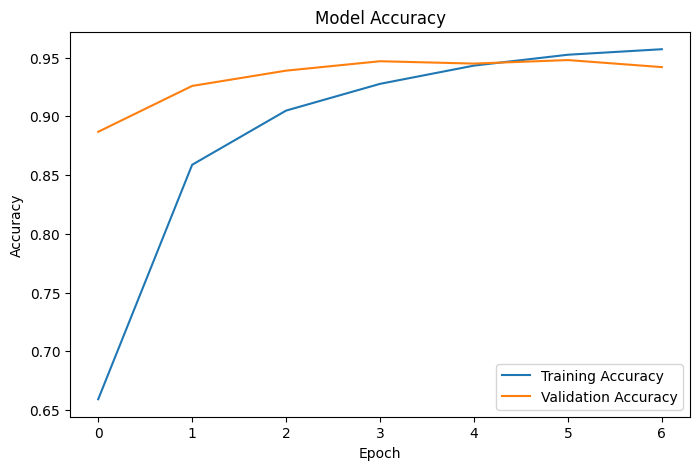

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    history2.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history2.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()


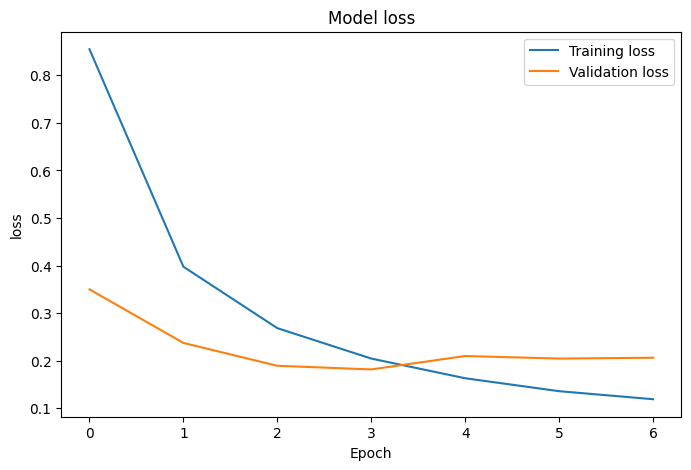

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    history2.history["loss"],
    label="Training loss"
)

plt.plot(
    history2.history["val_loss"],
    label="Validation loss"
)

plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.legend()

plt.show()

In [53]:
GRU_model.evaluate(X_val,Y_val)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9469 - loss: 0.1814


[0.1813831329345703, 0.946946918964386]

In [54]:
def predict_sentiment(Text,GRU_model):

    Text = clean_text(Text)

    sequence = tokenizer.texts_to_sequences([Text])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="pre",
        truncating="pre"
    )

    prediction = GRU_model.predict(
        padded,
        verbose=0
    )[0]

    labels = {
        0: "Neutral",
        1: "Positive",
        2: "Negative",
        3: "Irrelevant"
    }

    predicted_class = np.argmax(prediction)

    sentiment = labels[predicted_class]

    confidence = prediction[predicted_class]

    print(f"Text       : {Text}")
    print(f"Sentiment  : {sentiment}")
    print(f"Confidence : {confidence:.4f}")

In [55]:

predict_sentiment("Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!",GRU_model)

print("="*50)

predict_sentiment("This update completely ruined the app. It's slow, full of bugs, and keeps crashing.",GRU_model)

Text       : Just got my dream job! 😍🎉 I'm so excited to start this new journey. Feeling truly blessed!
Sentiment  : Positive
Confidence : 0.8679
Text       : This update completely ruined the app. It's slow, full of bugs, and keeps crashing.
Sentiment  : Negative
Confidence : 0.9999


In [57]:
import joblib

joblib.dump(tokenizer, "backend/tokenizer.pkl")

['backend/tokenizer.pkl']

In [56]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.21.0
3.15.0
